In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.utils import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    journal_plot_pack,
)
from sklearn.preprocessing import StandardScaler

In [3]:
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [5]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val pseudo-R²:         0.4740
Val log-likelihood:    2301.52
Val deviance:          6.29
Test pseudo-R²:        0.5115
Test log-likelihood:   3256.04
Test deviance:         7.41

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val pseudo-R²:         0.4718
Val log-likelihood:    2337.34
Val deviance:          6.26
Test pseudo-R²:        0.5064
Test log-likelihood:   3052.80
Test deviance:         7.29

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val pseudo-R²:         0.4556
Val log-likelihood:    2273.83
Val deviance:          6.49
Test pseudo-R²:        0.5150
Test log-likelihood:   2831.73
Test deviance:         6.77

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
Val pseud

In [6]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {

In [7]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val metrics:           (not available)
Test pseudo-R²:        0.4958
Test log-likelihood:   5557.57
Test deviance:         6.85

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val metrics:           (not available)
Test pseudo-R²:        0.4913
Test log-likelihood:   5390.14
Test deviance:         6.78

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val metrics:           (not available)
Test pseudo-R²:        0.4878
Test log-likelihood:   5105.56
Test deviance:         6.63

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
Val metrics:           (not available)
Test pseudo-R²:        0.4814
Test log-likelihood:   5276.44
Test deviance:         6.95

--- Cell 4.0 ---
Train pseudo-

In [8]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8704
Train log-likelihood:  16527.43
Train deviance:        1.54
Val pseudo-R²:         0.8072
Val log-likelihood:    3198.64
Val deviance:          2.31
Test pseudo-R²:        0.7658
Test log-likelihood:   4123.80
Test deviance:         3.55

--- Cell 1.0 ---
Train pseudo-R²:       0.8721
Train log-likelihood:  16809.31
Train deviance:        1.54
Val pseudo-R²:         0.7806
Val log-likelihood:    3161.22
Val deviance:          2.60
Test pseudo-R²:        0.7638
Test log-likelihood:   3908.56
Test deviance:         3.49

--- Cell 2.0 ---
Train pseudo-R²:       0.8702
Train log-likelihood:  16600.22
Train deviance:        1.51
Val pseudo-R²:         0.7785
Val log-likelihood:    3140.46
Val deviance:          2.64
Test pseudo-R²:        0.7634
Test log-likelihood:   3611.92
Test deviance:         3.30

--- Cell 3.0 ---
Train pseudo-R²:       0.8672
Train log-likelihood:  16456.14
Train deviance:        1.56
Val p

In [9]:
xgboost_results["best_params"]

{0.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
  

In [10]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8632
Train log-likelihood:  16436.94
Train deviance:        1.62
Val metrics:           (not available)
Test pseudo-R²:        0.7875
Test log-likelihood:   7340.95
Test deviance:         2.89

--- Cell 1.0 ---
Train pseudo-R²:       0.8604
Train log-likelihood:  16661.33
Train deviance:        1.68
Val metrics:           (not available)
Test pseudo-R²:        0.7769
Test log-likelihood:   7102.70
Test deviance:         2.97

--- Cell 2.0 ---
Train pseudo-R²:       0.8617
Train log-likelihood:  16496.34
Train deviance:        1.61
Val metrics:           (not available)
Test pseudo-R²:        0.7773
Test log-likelihood:   6792.26
Test deviance:         2.88

--- Cell 3.0 ---
Train pseudo-R²:       0.8566
Train log-likelihood:  16324.75
Train deviance:        1.69
Val metrics:           (not available)
Test pseudo-R²:        0.7819
Test log-likelihood:   7088.42
Test deviance:         2.92

--- Cell 4.0 ---
Train pse

In [11]:
# Neural Network hyperparameter grids
nn_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

In [12]:
# Per-cell Neural Network with grid search
nn_results = run_experiment(
    "NN-PerCell",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "epochs": 30,
        "grid_search": True,
        "k_folds": 2,
        "model_param_grid": nn_model_param_grid,
        "trainer_param_grid": nn_trainer_param_grid,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== NN-PerCell Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.9046
Train log-likelihood:  16952.87
Train deviance:        1.13
Val pseudo-R²:         0.9025
Val log-likelihood:    3455.23
Val deviance:          1.17
Test pseudo-R²:        0.8983
Test log-likelihood:   4575.70
Test deviance:         1.54

--- Cell 1.0 ---
Train pseudo-R²:       0.8667
Train log-likelihood:  16741.01
Train deviance:        1.61
Val pseudo-R²:         0.8575
Val log-likelihood:    3366.51
Val deviance:          1.69
Test pseudo-R²:        0.8577
Test log-likelihood:   4220.75
Test deviance:         2.10

--- Cell 2.0 ---
Train pseudo-R²:       0.9163
Train log-likelihood:  17162.15
Train deviance:        0.97
Val pseudo-R²:         0.8909
Val log-likelihood:    3442.06
Val deviance:          1.30
Test pseudo-R²:        0.9059
Test log-likelihood:   4059.65
Test deviance:         1.31

--- Cell 3.0 ---
Train pseudo-R²:       0.8514
Train log-likelihood:  16261.60
Train deviance:        1.75
Va

In [13]:
nn_results["best_params"]

{0.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 1.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 2.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 3.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 4.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 10.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 11.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 1e-05}},
 12.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 13.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0001}},
 14.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 25.0: {'model_params': {'hidden_sizes': (64, 32)},
  't

In [14]:
# Per-cell Neural Network without grid search (for comparison)
nn_nogs_results = run_experiment(
    "NN-PerCell-NoGS",
    fit_poisson_nn,
    {
        "batch_size": "auto",
        "hidden_sizes": [64, 32],
        "l1_lambda": 0.0,
        "grid_search": False,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)

Preparing datasets with train_frac=0.7, val_frac=0.15, use_val=True

=== Network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
          Softplus-6                    [-1, 1]               0
Total params: 2,497
Trainable params: 2,497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------
=== end architecture summary ===


=== Final network architecture su

In [15]:
# Transfer Learning hyperparameter grids
tl_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [16]:
# Transfer Learning NN with grid search
nn_tl_results = run_experiment(
    "NN-TL",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "grid_search": True,
        "model_param_grid": tl_model_param_grid,
        "trainer_param_grid": tl_trainer_param_grid,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)


===== NN-TL Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2320
Test log-likelihood:   2302.85
Test deviance:         11.64

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1772
Test log-likelihood:   1958.77
Test deviance:         12.15

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2244
Test log-likelihood:   1918.88
Test deviance:         10.83

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1467
Test log-likelihood:   1801.56
Test deviance:         12.29

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1747
Test log-likelihood:   2005.49
Test deviance:         12.16

--- Cell 10.0 ---
Train metrics:         (

In [17]:
nn_tl_results["best_params"]

{'model_params': {'hidden_sizes': (64, 32)},
 'trainer_params': {'l1_lambda': 0.0}}

In [18]:
# Transfer Learning NN without grid search (for comparison)
nn_tl_nogs_results = run_experiment(
    "NN-TL-NoGS",
    fit_poisson_nn_transfer_learning,
    {
        "batch_size": "auto",
        "hidden_sizes": (64, 32),
        "l1_lambda": 1e-4,
        "grid_search": False,
        "verbose": True,
    },
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir="../data/models",
    base_results_dir="../data/results",
)

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4                   [-1, 32]               0
            Linear-5                    [-1, 1]              33
          Softplus-6                    [-1, 1]               0
SharedHiddenPoissonNN-7                       [-1]               0
Total params: 2,497
Trainable params: 2,497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------
=== end architecture summa

In [19]:
# Prepare comparison data for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (nn_results["results"], "NN-PerCell"),
    (nn_tl_results["results"], "NN-TL"),
]

cells_gs = sorted(glm_results["results"].keys())

In [20]:
# Build comparison dataframe with test R2 scores
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf = pd.DataFrame(data_rows)
df_test_perf

,cell,GLM,XGBoost,NN-PerCell,NN-TL
0,0.0,0.511454,0.765825,0.898292,0.232040
1,1.0,0.506373,0.763823,0.857744,0.177240
2,2.0,0.514983,0.763364,0.905904,0.224370
3,3.0,0.497466,0.759938,0.857563,0.146688
4,4.0,0.501561,0.756861,0.901512,0.174677
5,10.0,0.412066,0.704449,0.775432,0.063633
6,11.0,0.428756,0.716208,0.775631,0.081534
7,12.0,0.467753,0.727279,0.805438,0.092019
8,13.0,0.448820,0.718115,0.804600,0.110520
9,14.0,0.425786,0.684994,0.760800,0.123047


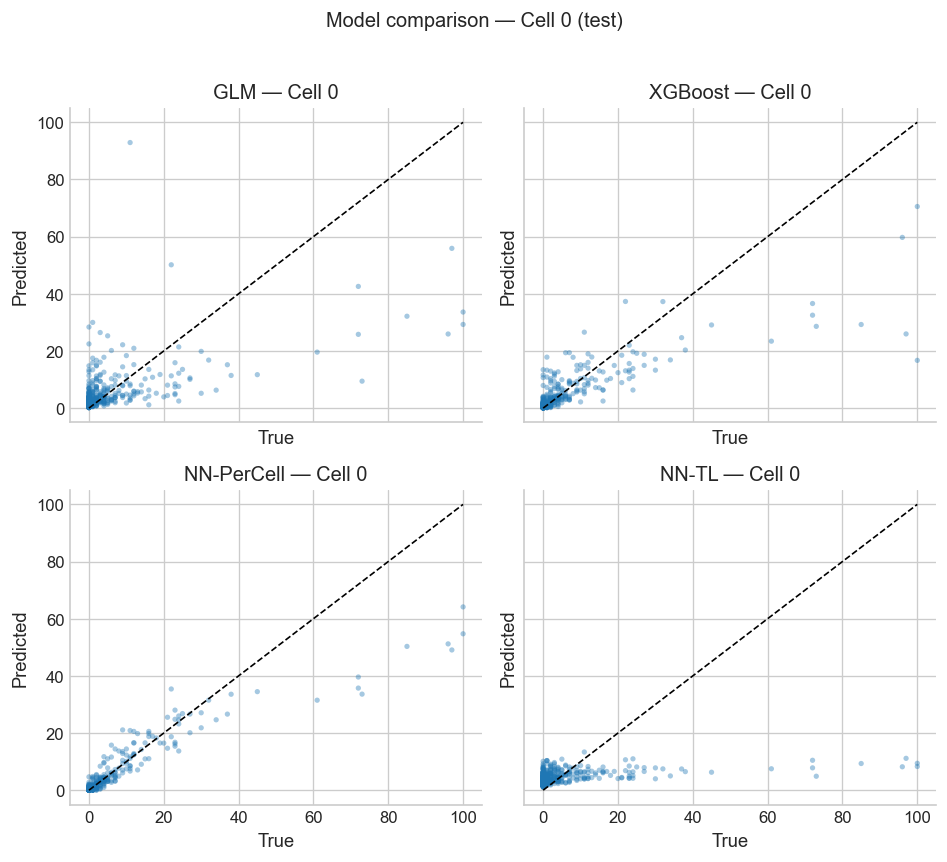

In [22]:
# Compare models for a single cell
compare_models_for_cell(model_results_gs, cell=0, split="test")

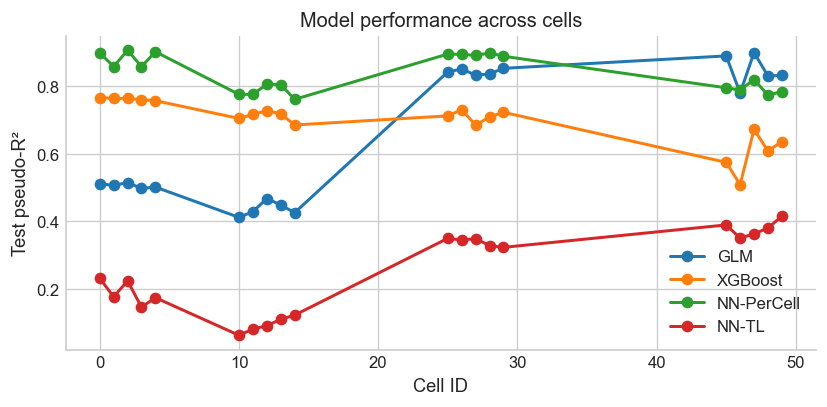

In [23]:
# Summary of R2 across all cells
compare_r2_across_cells(model_results_gs, split="test")

In [24]:
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (nn_nogs_results["results"], "NN-PerCell (No GS)"),
    (nn_tl_nogs_results["results"], "NN-TL (No GS)"),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [25]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf = pd.DataFrame(data_rows)
df_test_perf

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell (No GS),NN-TL (No GS)
0,0.0,0.495828,0.787478,0.861031,0.060422
1,1.0,0.491330,0.776923,0.826463,0.083404
2,2.0,0.487759,0.777255,0.873596,0.095835
3,3.0,0.481392,0.781882,0.840516,0.070771
4,4.0,0.472272,0.763104,0.881289,0.102744
5,10.0,0.413206,0.690789,0.773188,0.113496
6,11.0,0.439885,0.710068,0.786210,0.180359
7,12.0,0.454806,0.729184,0.803983,0.054956
8,13.0,0.438039,0.709677,0.798103,0.140033
9,14.0,0.431220,0.694672,0.758919,0.071886


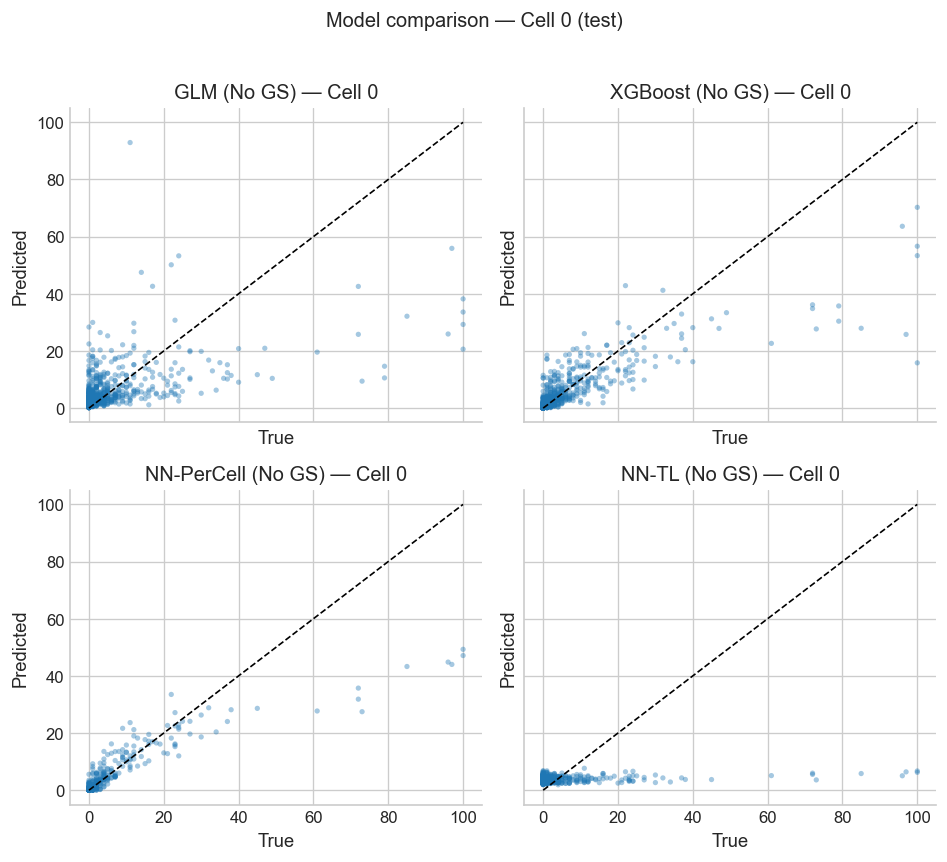

In [26]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

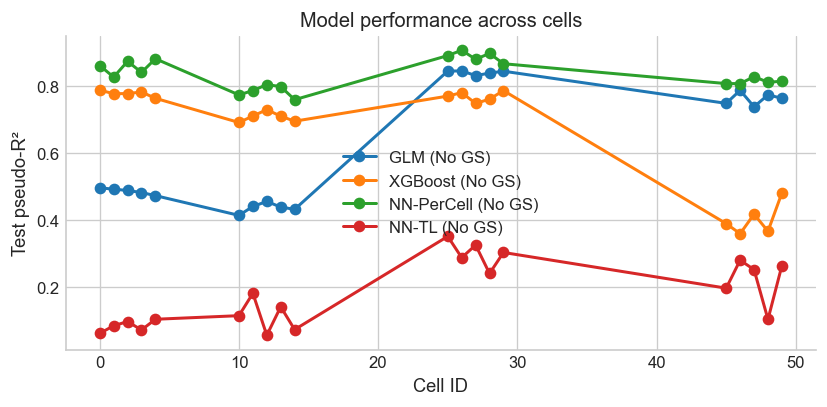

In [27]:
compare_r2_across_cells(model_results_nogs, split="test")

In [30]:
# Generate full journal publication-quality plots for all cells and save them
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir="../data/results",
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 21 plots
  ..\data\results\journal\cell_46.0.png
  ..\data\results\journal\cell_47.0.png
  ..\data\results\journal\cell_48.0.png
  ..\data\results\journal\cell_49.0.png
  ..\data\results\journal\r2_summary.png


In [29]:
# the network architecture diagram is generated automatically for torch models
import os

arch_path = os.path.join("..", "data", "results", "NN-PerCell", "architecture.png")
print("Per-cell NN architecture saved at:", arch_path)

Per-cell NN architecture saved at: ..\data\results\NN-PerCell\architecture.png
